In [2]:
import time
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

In [3]:
spark = SparkSession.builder.appName("PartitioningLabBenchmark").getOrCreate()

In [5]:
df = spark.range(0, 50_000_000).withColumn("user_id", col("id") % 1_000_000)

In [6]:
# Default shuffle partitions
spark.conf.set("spark.sql.shuffle.partitions", 200)

start_default = time.time()
df.groupBy("user_id").count().collect()
time_default = time.time() - start_default

print(f"Default shuffle partitions (200) time: {time_default:.2f} seconds")

Default shuffle partitions (200) time: 9.83 seconds


In [7]:
# BeOptimized partitions (repartition by user_id)
start_opt = time.time()
df_opt = df.repartition(64, "user_id")
df_opt.groupBy("user_id").count().collect()
time_opt = time.time() - start_opt

print(f"Optimized partitions (64) time: {time_opt:.2f} seconds")

Optimized partitions (64) time: 6.81 seconds


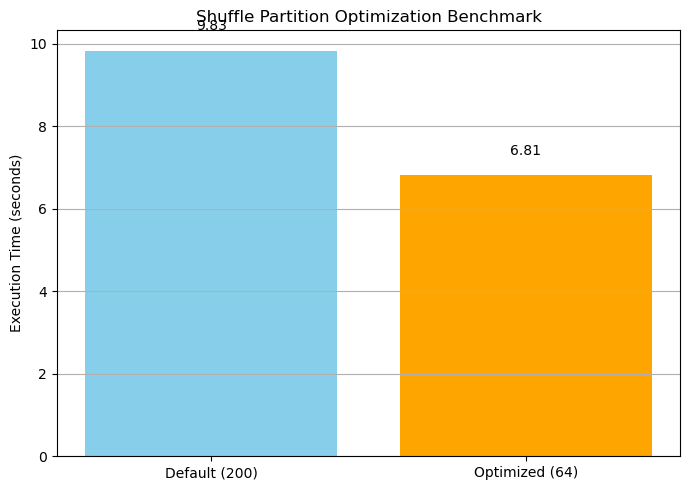

In [8]:
# Bar chart
labels = ["Default (200)", "Optimized (64)"]
times = [time_default, time_opt]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, times, color=["skyblue", "orange"])
plt.ylabel("Execution Time (seconds)")
plt.title("Shuffle Partition Optimization Benchmark")

# Annotate bars with values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}", ha="center")

plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [9]:
# Summary
print("\n=== Benchmark Summary ===")
print(f"Default partitions (200): {time_default:.2f} s")
print(f"Optimized partitions (64): {time_opt:.2f} s")
print(f"Speedup: {time_default / time_opt:.2f}x")



=== Benchmark Summary ===
Default partitions (200): 9.83 s
Optimized partitions (64): 6.81 s
Speedup: 1.44x
